In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import netCDF4 as nc
import xarray as xr

import sys
sys.path.append("/home/z5297792/UNSW-MRes/MRes/modules") 
from utils import axis_ratio_from_Q, tangential_velocity


In [2]:
def doppio(x1, y1, u1, v1, x2, y2, u2, v2, degree=3, plot=False):
    def nan_return():
        nan2 = np.full((2, 2), np.nan)
        return np.nan, np.nan, np.nan, nan2, np.nan

    def clean(*arrs):
        arrs = [np.asarray(a, dtype=float).ravel() for a in arrs]
        mask = np.logical_and.reduce([np.isfinite(a) for a in arrs])
        return [a[mask] for a in arrs]

    def find_root(x, y, degree=3):
        if x.size < degree + 1:
            return np.nan

        try:
            coeffs = np.polyfit(x, y, degree)
            roots = np.roots(coeffs)
        except Exception:
            return np.nan

        real_roots = roots[np.isreal(roots)].real
        if real_roots.size == 0:
            return np.nan

        mid_x = np.median(x)
        return real_roots[np.argmin(np.abs(real_roots - mid_x))]

    def tangent_at_root(x, y, root_x, degree=3):
        if x.size < degree + 1 or not np.isfinite(root_x):
            return np.nan, np.nan, np.nan

        try:
            coeffs = np.polyfit(x, y, degree)
        except Exception:
            return np.nan, np.nan, np.nan

        p = np.poly1d(coeffs)
        dp = np.polyder(p)

        slope = dp(root_x)
        intercept = p(root_x) - slope * root_x

        y_fit = p(x)
        ss_tot = np.sum((y - np.mean(y))**2)
        ss_res = np.sum((y - y_fit)**2)
        r2 = 1.0 if np.isclose(ss_tot, 0) else 1 - ss_res / ss_tot

        return slope, intercept, r2

    x1, y1, u1, v1 = clean(x1, y1, u1, v1)
    x2, y2, u2, v2 = clean(x2, y2, u2, v2)

    if len(x1) == 0 or len(x2) == 0:
        return nan_return()

    pts1 = np.column_stack((x1, y1))
    pts2 = np.column_stack((x2, y2))

    common = np.array([p for p in pts1 if np.any(np.all(pts2 == p, axis=1))])

    if len(common) != 1:
        return nan_return()

    center_x, center_y = common[0]

    xx = x1 - center_x
    yy = y2 - center_y

    x0 = find_root(xx, v1, degree)
    y0 = find_root(yy, u2, degree)

    a1, a0, r2a = tangent_at_root(xx, u1, x0, degree)
    b1, b0, r2b = tangent_at_root(xx, v1, x0, degree)
    c1, c0, r2c = tangent_at_root(yy, u2, y0, degree)
    d1, d0, r2d = tangent_at_root(yy, v2, y0, degree)

    vals = [a1, a0, r2a, b1, b0, r2b, c1, c0, r2c, d1, d0, r2d]
    if not np.all(np.isfinite(vals)):
        return nan_return()

    print(pd.DataFrame({'a':[a0, a1], 'b': [b0, b1],
                        'c': [c0, c1], 'd': [d0, d1]}))

    # print(f'a1: {a1} or -d1: {-d1}')
    # a1 = a1 if r2a >= r2d else -d1

    Omega = np.sign(b1)*np.sqrt(-b1*c1-a1**2)

    Q = np.array([[b1, -a1], [-a1, -c1]])/Omega

    xc = (a0*a1+c1*d0)/Omega**2
    yc = (a0*b1-a1*d0)/Omega**2

    w = Omega * (Q[0,0] + Q[1,1])

    print(f'x0: {x0} or {-b0/b1}')
    print(f'y0: {y0} or {-c0/c1}')

    return xc + center_x, yc + center_y, w, Q, Omega
    

In [3]:
def out_core_param_fit(
    rho2, Qr, vt,
    Omega0=None, Rc0=None,
    plot=False, ax=None,
    maxfev=10000, Rc_max=1e5,
    r2_flag=False,
    rho_plot_max=None, n_curve=400,
    km_flag=False,
    ci_flag=False,
    pred_flag=False
):

    from scipy.optimize import curve_fit

    rho2 = np.asarray(rho2, float)
    Qr   = np.asarray(Qr, float)
    vt   = np.asarray(vt, float)

    m = np.isfinite(rho2) & np.isfinite(Qr) & np.isfinite(vt) & (rho2 >= 0) & (Qr != 0)
    if not np.any(m):
        return (np.nan, np.nan, np.nan, np.nan) if r2_flag else (np.nan, np.nan, np.nan)

    rho2 = rho2[m]
    Qr   = Qr[m]
    vt   = vt[m]

    rho = np.sqrt(rho2)
    vt = vt * (rho / Qr)

    def vt_model(r2, Omega, Rc):
        return Omega * np.sqrt(r2) * np.exp(-r2 / (Rc**2))

    i = np.nanargmax(np.abs(vt))
    rho_max = rho[i]

    if Rc0 is None:
        Rc0 = max(rho_max * np.sqrt(2), 1e-6)

    if Omega0 is None:
        denom = rho * np.exp(-rho2 / (Rc0**2))
        ok = np.abs(denom) > 0
        Omega0 = np.nanmedian(vt[ok] / denom[ok]) if np.any(ok) else 0

    if not np.isfinite(Omega0):
        Omega0 = 0

    pcov = None
    try:
        popt, pcov = curve_fit(
            vt_model, rho2, vt,
            p0=[Omega0, Rc0],
            bounds=([-np.inf, 1e-8], [np.inf, np.inf]),
            maxfev=maxfev
        )
        Omega_opt, Rc_opt = popt
    except:
        Omega_opt, Rc_opt = Omega0, Rc0

    if (not np.isfinite(Rc_opt)) or (Rc_opt > Rc_max):
        Omega_opt, Rc_opt = Omega0, Rc0
        pcov = None

    psi0_opt = -0.5 * Omega_opt * Rc_opt**2

    vt_fit = vt_model(rho2, Omega_opt, Rc_opt)

    ss_res = np.sum((vt - vt_fit)**2)
    ss_tot = np.sum((vt - vt.mean())**2)
    R2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    dof = max(len(vt) - 2, 1)
    sigma2 = ss_res / dof

    if plot:

        if ax is None:
            fig, ax = plt.subplots()

        if rho_plot_max is None:
            rho_plot_max = np.nanmax(rho)

        r_grid = np.linspace(0, rho_plot_max, n_curve)
        r2_grid = r_grid**2

        vt_grid = vt_model(r2_grid, Omega_opt, Rc_opt)

        if km_flag:
            core_mask = rho <= 30
        else:
            core_mask = rho <= 30_000

        ax.scatter(rho[core_mask], np.abs(vt[core_mask]), s=10, color='m', label='Core observed')
        ax.scatter(rho[~core_mask], np.abs(vt[~core_mask]), s=10, color='g', label='Outer-core observed')

        ax.plot(r_grid, np.abs(vt_grid), lw=2, color='b', label='')
        ax.axvline(Rc_opt / np.sqrt(2), ls='--', color='r', label='', lw=2)

        if pcov is not None:

            exp_term = np.exp(-r2_grid / (Rc_opt**2))

            dOmega = np.sqrt(r2_grid) * exp_term
            dRc = 2 * Omega_opt * (r2_grid**1.5) * exp_term / (Rc_opt**3)

            J = np.vstack([dOmega, dRc]).T
            var_model = np.einsum("ij,jk,ik->i", J, pcov, J)

            if ci_flag:
                se_model = np.sqrt(np.maximum(var_model, 0))
                lo = vt_grid - 1.96 * se_model
                hi = vt_grid + 1.96 * se_model

                ax.fill_between(
                    r_grid, np.abs(lo), np.abs(hi),
                    color='orange', alpha=.2, label='95% CI'
                )

            if pred_flag:
                se_pred = np.sqrt(np.maximum(var_model + sigma2, 0))
                lo = vt_grid - 1.96 * se_pred
                hi = vt_grid + 1.96 * se_pred

                ax.fill_between(
                    r_grid, np.abs(lo), np.abs(hi),
                    color='b', alpha=.15, label=''
                )

        ax.set_xlabel(r'$\rho$')
        ax.set_ylabel(r'$|v_t^\star|$')

        ax.set_title(
            f"Omega={Omega_opt:.3g}, Rc={Rc_opt:.3g}, psi0={psi0_opt:.3g}, R²={R2:.2f}"
        )

        ax.legend()

    return (Rc_opt, psi0_opt, Omega_opt, R2) if r2_flag else (Rc_opt, psi0_opt, Omega_opt)
    

In [4]:
def doppio_pipeliner(nxc, nyc, ut, vt, X_new, Y_new, r=30000.0):
    nan = (np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan)

    x = np.asarray(X_new[:, 0], float)
    y = np.asarray(Y_new[0, :], float)

    dx = np.nanmedian(np.abs(np.diff(x)))
    dy = np.nanmedian(np.abs(np.diff(y)))
    cell = np.nanmax([dx, dy])
    if not np.isfinite(cell) or cell == 0:
        return nan

    margin = int(np.ceil(r / cell))

    ic = int(np.clip(np.searchsorted(x, nxc), 1, x.size-1))
    ic -= (nxc - x[ic-1] < x[ic] - nxc)
    jc = int(np.clip(np.searchsorted(y, nyc), 1, y.size-1))
    jc -= (nyc - y[jc-1] < y[jc] - nyc)

    if ic < margin or ic >= x.size - margin or jc < margin or jc >= y.size - margin:
        return nan

    # x-transect (y = y[jc])
    i0 = np.searchsorted(x, nxc - r, side="left")
    i1 = np.searchsorted(x, nxc + r, side="right")
    x1 = x[i0:i1]
    y1 = np.full(x1.size, y[jc])
    u1 = ut[i0:i1, jc]
    v1 = vt[i0:i1, jc]

    # y-transect (x = x[ic])
    j0 = np.searchsorted(y, nyc - r, side="left")
    j1 = np.searchsorted(y, nyc + r, side="right")
    y2 = y[j0:j1]
    x2 = np.full(y2.size, x[ic])
    u2 = ut[ic, j0:j1]
    v2 = vt[ic, j0:j1]

    return x1, y1, u1, v1, x2, y2, u2, v2
    

### Numerical Data

In [5]:
ssh_path = '/srv/scratch/z5297792/ESP_Paper_Data/sat_data_copernicus_CCE_2023_1D.nc'
ds_nc = nc.Dataset(ssh_path)

lon, lat = ds_nc['longitude'][:], ds_nc['latitude'][:]
u = np.squeeze(ds_nc['uo'][:]); v = np.squeeze(ds_nc['vo'][:])
# u, v = np.transpose(u, (2,1,0)), np.transpose(v, (2,1,0))  # (time, lat, lon)
t = pd.Timestamp("1950-01-01") + pd.to_timedelta(ds_nc['time'][:], "h")
u, v = np.where(np.abs(u) < 100, u, np.nan), np.where(np.abs(v) < 100, v, np.nan)
lon2d, lat2d = np.meshgrid(lon, lat, indexing="xy")
theta_mean, phi_mean = 154.3, -37.9
x = (lon2d-theta_mean)*111000*np.cos(np.deg2rad(phi_mean))
y = (lat2d-phi_mean)*111000
ds_cop = xr.Dataset(
    {"u": (("time","lat","lon"), u),
     "v": (("time","lat","lon"), v)},
    coords={"time": t, "lat": lat, "lon": lon,
            "x": (("lat","lon"), x),
            "y": (("lat","lon"), y)}
)
ds_cop["land_mask"] = np.isnan(ds_cop.u.isel(time=0)) & np.isnan(ds_cop.v.isel(time=0))
# # Time slice
ds_cop = ds_cop.sel(time=ds_cop.time <= np.datetime64('2024-01-27T00:00:00.000000000'))

print(ds_cop.time.min(), ds_cop.time.max())
print(ds_cop.lat.min(), ds_cop.lat.max())
print(ds_cop.lon.min(), ds_cop.lon.max())

ds_cop


<xarray.DataArray 'time' ()> Size: 8B
array('2023-10-19T00:00:00.000000000', dtype='datetime64[ns]') <xarray.DataArray 'time' ()> Size: 8B
array('2024-01-27T00:00:00.000000000', dtype='datetime64[ns]')
<xarray.DataArray 'lat' ()> Size: 4B
array(-42., dtype=float32) <xarray.DataArray 'lat' ()> Size: 4B
array(-34., dtype=float32)
<xarray.DataArray 'lon' ()> Size: 4B
array(149., dtype=float32) <xarray.DataArray 'lon' ()> Size: 4B
array(158., dtype=float32)


<xarray.Dataset> Size: 9MB
Dimensions:    (time: 101, lat: 97, lon: 109)
Coordinates:
  * time       (time) datetime64[ns] 808B 2023-10-19 ... 2024-01-27
  * lat        (lat) float32 388B -42.0 -41.92 -41.83 ... -34.17 -34.08 -34.0
  * lon        (lon) float32 436B 149.0 149.1 149.2 149.2 ... 157.8 157.9 158.0
    x          (lat, lon) float64 85kB -4.642e+05 -4.569e+05 ... 3.241e+05
    y          (lat, lon) float64 85kB -4.551e+05 -4.551e+05 ... 4.329e+05
Data variables:
    u          (time, lat, lon) float32 4MB -0.284 -0.3366 ... 0.3254 0.346
    v          (time, lat, lon) float32 4MB -0.2342 -0.1941 ... -0.1586 -0.1242
    land_mask  (lat, lon) bool 11kB False False False ... False False False

In [6]:
xc_pre, yc_pre = 0.0, 0.0
rows = []
xyuv_rows = []

X = ds_cop.x.values
Y = ds_cop.y.values

for t, time in enumerate(ds_cop.time.values):
    ut = ds_cop.u.sel(time=time).values
    vt = ds_cop.v.sel(time=time).values

    x1,y1,u1,v1,x2,y2,u2,v2 = doppio_pipeliner(xc_pre, yc_pre, ut.T, vt.T, X.T, Y.T, r=50_000)
    xc, yc, w, Q, Omega = doppio(x1,y1,u1,v1,x2,y2,u2,v2, plot=True)

    print(xc, yc, w, Q, Omega)

    ok = (np.isfinite(xc) and np.isfinite(yc) and
          (np.hypot(xc-xc_pre, yc-yc_pre) < 100_000) and (w < 0))

    if not ok:
        break

    rows.append(dict(xc=xc, yc=yc, w=w, Q=Q, Omega=Omega, time=time))
    xc_pre, yc_pre = xc, yc

    xi = np.concatenate([x1, x2])
    yi = np.concatenate([y1, y2])
    ui = np.concatenate([u1, u2])
    vi = np.concatenate([v1, v2])

    xyuv_rows.append(pd.DataFrame({
        "time": time,
        "core": "inner",
        "xi": xi, "yi": yi, "ui": ui, "vi": vi
    }))

df_res = pd.DataFrame(rows, columns=["xc","yc","w","Q","Omega","time"])
df_res["alpha"] = [axis_ratio_from_Q(Q) for Q in df_res["Q"].to_list()]

df_xyuv = pd.concat(xyuv_rows, ignore_index=True) if xyuv_rows else pd.DataFrame(
    columns=["time","core","xi","yi","ui","vi"]
)

df_res


          a         b         c         d
0 -0.037775 -0.180739 -0.035422 -0.167236
1 -0.000002 -0.000021  0.000020  0.000001
x0: -8799.395623855327 or -8799.395623855327
y0: 1806.80528325003 or 1806.8052832500296
-5111.404592436806 -843.3364294573339 -4.0144946591189005e-05 [[ 1.03004383 -0.11266276]
 [-0.11266276  0.98315515]] -1.9940873694126265e-05
          a         b         c         d
0 -0.043550  0.008103 -0.065563  0.014009
1 -0.000002 -0.000020  0.000021  0.000002
x0: 412.07559424965507 or 412.07559424965507
y0: 3100.9519190604215 or 3100.951919060422
-3447.854951366083 298.4473442350022 -4.0806004822094366e-05 [[ 0.96907077 -0.09885462]
 [-0.09885462  1.04200051]] -2.0290680522733594e-05
          a         b         c         d
0  0.070773 -0.045162  0.054087 -0.054422
1 -0.000003 -0.000019  0.000022  0.000002
x0: -2427.8962037704555 or -2427.896203770455
y0: -2451.9474536999787 or -2451.947453699979
-7812.073096946977 -5464.15654602643 -4.066016927473392e-05 [[ 0.9260127

,xc,yc,w,Q,Omega,time,alpha
0,-5111.404592,-843.336429,-0.000040,"[[1.030043830834252, -0.11266275631588453], [-...",-0.000020,2023-10-19 00:00:00,1.121676
1,-3447.854951,298.447344,-0.000041,"[[0.9690707730190414, -0.09885461754182674], [...",-0.000020,2023-10-19 23:56:15,1.110901
2,-7812.073097,-5464.156546,-0.000041,"[[0.9260127534658863, -0.1298871082567435], [-...",-0.000020,2023-10-21 00:00:00,1.167872
3,-3129.360452,-4589.055175,-0.000042,"[[0.8969911489120278, -0.13495677254314872], [...",-0.000021,2023-10-22 00:00:00,1.196046
4,-638.761454,-4833.074919,-0.000041,"[[0.8197263557743001, -0.05800403913632506], [...",-0.000020,2023-10-22 23:56:15,1.232181
...,...,...,...,...,...,...,...
96,-251178.930029,167583.373934,-0.000028,"[[1.2642565786135038, 0.016447883038695422], [...",-0.000013,2024-01-23 00:00:00,1.264828
97,-254391.835702,162956.595003,-0.000021,"[[1.65584430475614, -0.2381831706445523], [-0....",-0.000009,2024-01-24 00:00:00,1.708832
98,-268348.695744,155171.585124,-0.000018,"[[1.3598525069977128, -0.4768950087458135], [-...",-0.000008,2024-01-25 00:00:00,1.660097
99,-259891.869991,167599.481372,-0.000017,"[[1.2863182976525362, -0.6107981044967211], [-...",-0.000007,2024-01-26 00:00:00,1.797406


(np.float64(-281770.2469244026),
 np.float64(13503.87905248611),
 np.float64(-18538.09238921955),
 np.float64(192008.6213102932))

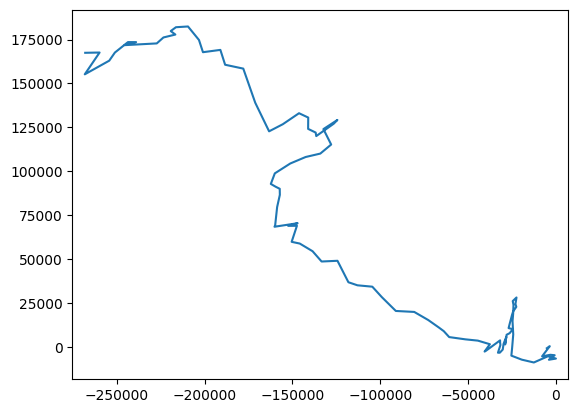

In [7]:
plt.plot(df_res.xc, df_res.yc)
plt.axis('equal')


,xc,yc,w,Q,Omega,time,alpha,Rc,psi0
0,-5111.404592,-843.336429,-0.000036,"[[1.030043830834252, -0.11266275631588453], [-...",-0.000018,2023-10-19 00:00:00,1.121676,84643.475695,63374.641278
1,-3447.854951,298.447344,-0.000036,"[[0.9690707730190414, -0.09885461754182674], [...",-0.000018,2023-10-19 23:56:15,1.110901,83465.163313,62445.712810
2,-7812.073097,-5464.156546,-0.000036,"[[0.9260127534658863, -0.1298871082567435], [-...",-0.000018,2023-10-21 00:00:00,1.167872,84799.031865,63187.862774
3,-3129.360452,-4589.055175,-0.000037,"[[0.8969911489120278, -0.13495677254314872], [...",-0.000018,2023-10-22 00:00:00,1.196046,83141.364047,62877.605787
4,-638.761454,-4833.074919,-0.000037,"[[0.8197263557743001, -0.05800403913632506], [...",-0.000018,2023-10-22 23:56:15,1.232181,82780.014086,62458.025154
...,...,...,...,...,...,...,...,...,...
96,-251178.930029,167583.373934,-0.000035,"[[1.2642565786135038, 0.016447883038695422], [...",-0.000017,2024-01-23 00:00:00,1.264828,62188.190961,33040.595294
97,-254391.835702,162956.595003,-0.000033,"[[1.65584430475614, -0.2381831706445523], [-0....",-0.000014,2024-01-24 00:00:00,1.708832,66807.934868,31920.003886
98,-268348.695744,155171.585124,-0.000029,"[[1.3598525069977128, -0.4768950087458135], [-...",-0.000013,2024-01-25 00:00:00,1.660097,71130.566509,31941.124659
99,-259891.869991,167599.481372,-0.000022,"[[1.2863182976525362, -0.6107981044967211], [-...",-0.000009,2024-01-26 00:00:00,1.797406,83316.095409,32606.988924


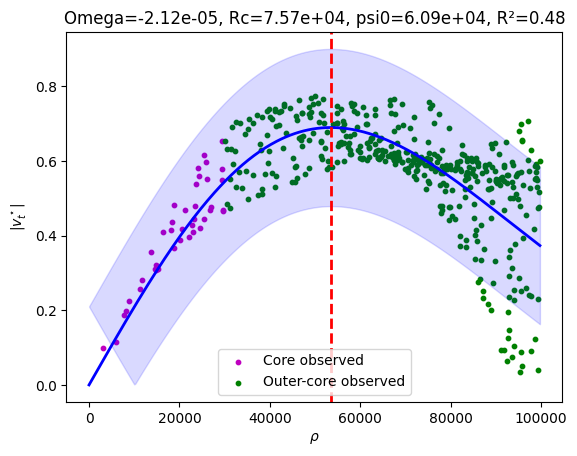

In [8]:
rho_outer = 100_000.0

xi0 = ds_cop.x.values.ravel()
yi0 = ds_cop.y.values.ravel()

Rc_opts, psi0_opts, Omega_opts = [], [], []
xyuv_rows = []

for k, data in df_res.iterrows():
    time = data.time

    ui0 = ds_cop.u.sel(time=time).values.ravel()
    vi0 = ds_cop.v.sel(time=time).values.ravel()

    xc, yc = float(data.xc), float(data.yc)
    Q = np.asarray(data.Q)
    Omega = float(data.Omega)
    q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]

    dx = xi0 - xc
    dy = yi0 - yc
    rho2 = q11*dx*dx + 2*q12*dx*dy + q22*dy*dy

    outer = rho2 <= rho_outer**2
    xi_o, yi_o = xi0[outer], yi0[outer]
    ui_o, vi_o = ui0[outer], vi0[outer]
    dx_o, dy_o, rho2_o = dx[outer], dy[outer], rho2[outer]

    xyuv_rows.append(pd.DataFrame({
        "time": time, "core": "outer",
        "xi": xi_o, "yi": yi_o, "ui": ui_o, "vi": vi_o
    }))

    vt_o = tangential_velocity(xi_o, yi_o, ui_o, vi_o, xc, yc, Q)
    Qr_o = np.sqrt((q11*dx_o + q12*dy_o)**2 + (q12*dx_o + q22*dy_o)**2)

    sign_mask = (vt_o <= 0) if (Omega < 0) else (vt_o >= 0)
    rho2_f, Qr_f, vt_f = rho2_o[sign_mask], Qr_o[sign_mask], vt_o[sign_mask]

    Rc_opt, psi0_opt, Omega_opt = out_core_param_fit(rho2_f, Qr_f, vt_f, Omega0=Omega, plot=(k == 10), pred_flag=True)
    Rc_opts.append(Rc_opt); psi0_opts.append(psi0_opt); Omega_opts.append(Omega_opt)

df_xyuv_o = pd.concat(xyuv_rows, ignore_index=True) if xyuv_rows else pd.DataFrame(
    columns=["time","core","xi","yi","ui","vi"]
)

df_xyuv = pd.concat([df_xyuv, df_xyuv_o], ignore_index=True)
df_xyuv = (
    df_xyuv
    .sort_values(by="core", key=lambda s: s.eq("outer"))  # keep inner first
    .drop_duplicates(subset=["time", "xi", "yi", "ui", "vi"], keep="first")
    .reset_index(drop=True)
)

df_res["Rc"] = Rc_opts
df_res["psi0"] = psi0_opts
df_res["Omega"] = Omega_opts
df_res["w"] = [Omega*(Q[0,0] + Q[1,1]) for (Omega,Q) in zip(df_res.Omega, df_res.Q)]
df_res


In [9]:
# Find R2
def model_uv_at_xy(xi, yi, xc, yc, Q, Omega, Rc):
    dx = xi - xc
    dy = yi - yc

    q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]

    rho2 = q11*dx*dx + 2*q12*dx*dy + q22*dy*dy
    fac = Omega * np.exp(-rho2 / (Rc*Rc))

    uhat = -fac * (q12*dx + q22*dy)
    vhat =  fac * (q11*dx + q12*dy)

    return uhat, vhat
    
def vector_R2(u, v, uhat, vhat):
    m = np.isfinite(u) & np.isfinite(v) & np.isfinite(uhat) & np.isfinite(vhat)
    if not np.any(m):
        return np.nan
    u, v, uhat, vhat = u[m], v[m], uhat[m], vhat[m]
    err2 = (uhat - u)**2 + (vhat - v)**2
    u0, v0 = np.mean(u), np.mean(v)
    tot2 = (u - u0)**2 + (v - v0)**2
    return 1 - np.sum(err2)/np.sum(tot2) if np.sum(tot2) > 0 else np.nan

R2_vals = []
for _, row in df_res.iterrows():
    df = df_xyuv[df_xyuv.time == row.time]
    xi = df.xi.to_numpy(float)
    yi = df.yi.to_numpy(float)
    u  = df.ui.to_numpy(float)
    v  = df.vi.to_numpy(float)
    uhat, vhat = model_uv_at_xy(xi, yi, row.xc, row.yc, np.asarray(row.Q), row.Omega, row.Rc)
    R2_vals.append(vector_R2(u, v, uhat, vhat))
df_res['R2'] = R2_vals
df_res


,xc,yc,w,Q,Omega,time,alpha,Rc,psi0,R2
0,-5111.404592,-843.336429,-0.000036,"[[1.030043830834252, -0.11266275631588453], [-...",-0.000018,2023-10-19 00:00:00,1.121676,84643.475695,63374.641278,0.941574
1,-3447.854951,298.447344,-0.000036,"[[0.9690707730190414, -0.09885461754182674], [...",-0.000018,2023-10-19 23:56:15,1.110901,83465.163313,62445.712810,0.953377
2,-7812.073097,-5464.156546,-0.000036,"[[0.9260127534658863, -0.1298871082567435], [-...",-0.000018,2023-10-21 00:00:00,1.167872,84799.031865,63187.862774,0.922703
3,-3129.360452,-4589.055175,-0.000037,"[[0.8969911489120278, -0.13495677254314872], [...",-0.000018,2023-10-22 00:00:00,1.196046,83141.364047,62877.605787,0.950536
4,-638.761454,-4833.074919,-0.000037,"[[0.8197263557743001, -0.05800403913632506], [...",-0.000018,2023-10-22 23:56:15,1.232181,82780.014086,62458.025154,0.954572
...,...,...,...,...,...,...,...,...,...,...
96,-251178.930029,167583.373934,-0.000035,"[[1.2642565786135038, 0.016447883038695422], [...",-0.000017,2024-01-23 00:00:00,1.264828,62188.190961,33040.595294,0.404334
97,-254391.835702,162956.595003,-0.000033,"[[1.65584430475614, -0.2381831706445523], [-0....",-0.000014,2024-01-24 00:00:00,1.708832,66807.934868,31920.003886,0.464172
98,-268348.695744,155171.585124,-0.000029,"[[1.3598525069977128, -0.4768950087458135], [-...",-0.000013,2024-01-25 00:00:00,1.660097,71130.566509,31941.124659,0.382438
99,-259891.869991,167599.481372,-0.000022,"[[1.2863182976525362, -0.6107981044967211], [-...",-0.000009,2024-01-26 00:00:00,1.797406,83316.095409,32606.988924,0.416127


In [10]:
X = ds_cop.x.values
Y = ds_cop.y.values
nt = len(df_res)

U = np.empty((nt, X.shape[0], X.shape[1]))
V = np.empty((nt, X.shape[0], X.shape[1]))

for k in range(nt):
    data = df_res.iloc[k]

    dx = X - data.xc
    dy = Y - data.yc

    q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]

    rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2
    fac = data.Omega * np.exp(-rho2 / data.Rc**2)

    U[k] = -fac * (q12*dx + q22*dy)
    V[k] =  fac * (q11*dx + q12*dy)

mask = ds_cop.land_mask.values[None, :, :]   # (1, lat, lon)
U = np.where(mask, np.nan, U)
V = np.where(mask, np.nan, V)

ds_model = xr.Dataset(
    data_vars=dict(
        u=(("time","lat","lon"), U),
        v=(("time","lat","lon"), V),
    ),
    coords=dict(
        time=df_res.time.values,
        lat=ds_cop.lat.values,
        lon=ds_cop.lon.values,
        x=(("lat","lon"), X),
        y=(("lat","lon"), Y),
    ),
)


In [11]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.dates as mdates

def plot__model(df_res, ds_cop, ds_model, df_xyuv, time=None, spac=1, scale=20,
                xlim=(-410, 200), ylim=(-160, 260), out_thresh=False, plot_data=False):

    if time is None:
        time = ds_model.time.values[0]

    sat = ds_cop.sel(time=time, method="nearest")
    mod = ds_model.sel(time=time, method="nearest")
    data = df_res[df_res.time == time].iloc[0]

    X = sat.x.values / 1e3
    Y = sat.y.values / 1e3

    us, vs = sat.u.values, sat.v.values
    um, vm = mod.u.values, mod.v.values

    sp_s = np.hypot(us, vs)
    sp_m = np.hypot(um, vm)

    dx, dy = sat.x.values - data.xc, sat.y.values - data.yc
    q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]
    rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2

    roi = (X >= xlim[0]) & (X <= xlim[1]) & (Y >= ylim[0]) & (Y <= ylim[1])
    sp_s_roi = np.where(roi, sp_s, np.nan)
    sp_m_roi = np.where(roi, sp_m, np.nan)
    roi_quiv = roi & (rho2 >= 100_000**2)

    vals = np.concatenate([sp_s_roi[roi], sp_m_roi[roi]])
    vmax = np.nanmax(vals)
    levels = np.arange(0, vmax + .05, .05)

    X_rho, Y_rho = np.meshgrid(np.linspace(xlim[0]*1e3, xlim[1]*1e3, 100),
                               np.linspace(ylim[0]*1e3, ylim[1]*1e3, 100))
    dx = X_rho - data.xc
    dy = Y_rho - data.yc
    rho2 = data.Q[0,0]*dx**2 + 2*data.Q[0,1]*dx*dy + data.Q[1,1]*dy**2

    fig, axs = plt.subplots(1, 2, figsize=(15, 7), sharex=True, sharey=True, constrained_layout=True)

    # ----- coloured center path -----
    x_path = df_res.xc.to_numpy() / 1e3
    y_path = df_res.yc.to_numpy() / 1e3
    t_path = pd.to_datetime(df_res.time)
    t_num = mdates.date2num(t_path)

    pts = np.array([x_path, y_path]).T.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)

    norm_t = Normalize(t_num.min(), t_num.max())
    lc0 = LineCollection(segs, cmap="plasma", norm=norm_t, linewidth=2, zorder=2)
    lc0.set_array(t_num[:-1])

    lc1 = LineCollection(segs, cmap="plasma", norm=norm_t, linewidth=2, zorder=2)
    lc1.set_array(t_num[:-1])

    # ---- Numerical model ----
    h0 = axs[0].contourf(X, Y, sp_s_roi, levels=levels, cmap="Blues_r")

    axs[0].quiver(X[::spac,::spac], Y[::spac,::spac],
                  np.where(roi_quiv[::spac,::spac], us[::spac,::spac], np.nan),
                  np.where(roi_quiv[::spac,::spac], vs[::spac,::spac], np.nan),
                  scale=scale, width=.0015, alpha=.4)

    axs[0].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50, zorder=3)
    axs[0].add_collection(lc0)
    axs[0].contour(X_rho/1e3, Y_rho/1e3, rho2, levels=[(data.Rc**2)/2], colors="r", linewidths=2, linestyles='--', zorder=3)

    if plot_data:
        df = df_xyuv[(df_xyuv.time == time) & (df_xyuv.core == 'outer')]
        axs[0].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi, scale=scale, width=.001, color='g', label='Outer-core data', zorder=1)
        df = df_xyuv[(df_xyuv.time == time) & (df_xyuv.core == 'inner')]
        axs[0].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi, scale=scale, width=.0025, color='m', label='Core data', zorder=3)

    axs[0].set_title("Numerical Model")
    axs[0].set_aspect("equal")
    axs[0].legend(loc='lower left')

    # ---- Fitted model ----
    h1 = axs[1].contourf(X, Y, sp_m_roi, levels=levels, cmap="Blues_r")
    axs[1].quiver(X[::spac,::spac], Y[::spac,::spac],
                  np.where(roi[::spac,::spac], um[::spac,::spac], np.nan),
                  np.where(roi[::spac,::spac], vm[::spac,::spac], np.nan),
                  scale=scale, width=.0015, alpha=.5)
    axs[1].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50, label='Eddy center', zorder=3)
    axs[1].plot([np.nan, np.nan], [np.nan, np.nan], lw=2, color='r', label='Max tangential\nvelocity', ls='--')
    axs[1].add_collection(lc1)
    axs[1].contour(X_rho/1e3, Y_rho/1e3, rho2, levels=[(data.Rc**2)/2], colors="r", linewidths=2, linestyles='--', zorder=3)

    axs[1].set_title("Model - DOPPIO with Numerical Data")
    axs[1].set_aspect("equal")
    axs[1].legend(loc='lower left')

    gap = 20
    for ax in axs:
        ax.set_xlim(xlim[0] + gap, xlim[1] - gap)
        ax.set_ylim(ylim[0] + gap, ylim[1] - gap)
        ax.set_xlabel("x (km)")
    axs[0].set_ylabel("y (km)")

    axs[0].text(-0.05, 1.05, "a)", transform=axs[0].transAxes, fontsize=13, fontweight="bold", va="top", ha="left")
    axs[1].text(-0.05, 1.05, "b)", transform=axs[1].transAxes, fontsize=13, fontweight="bold", va="top", ha="left")

    # speed colourbar
    cbar1 = fig.colorbar(h1, ax=axs, label="Current speed (m s$^{-1}$)", fraction=0.0165, pad=0.02)

    # time colourbar on far right
    cbar2 = fig.colorbar(lc1, ax=axs, fraction=0.0165, pad=0.025)
    cbar2.set_label("Center path time")
    cbar2.ax.yaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))

    print(time)
    plt.show()



2023-10-22T00:00:00.000000000


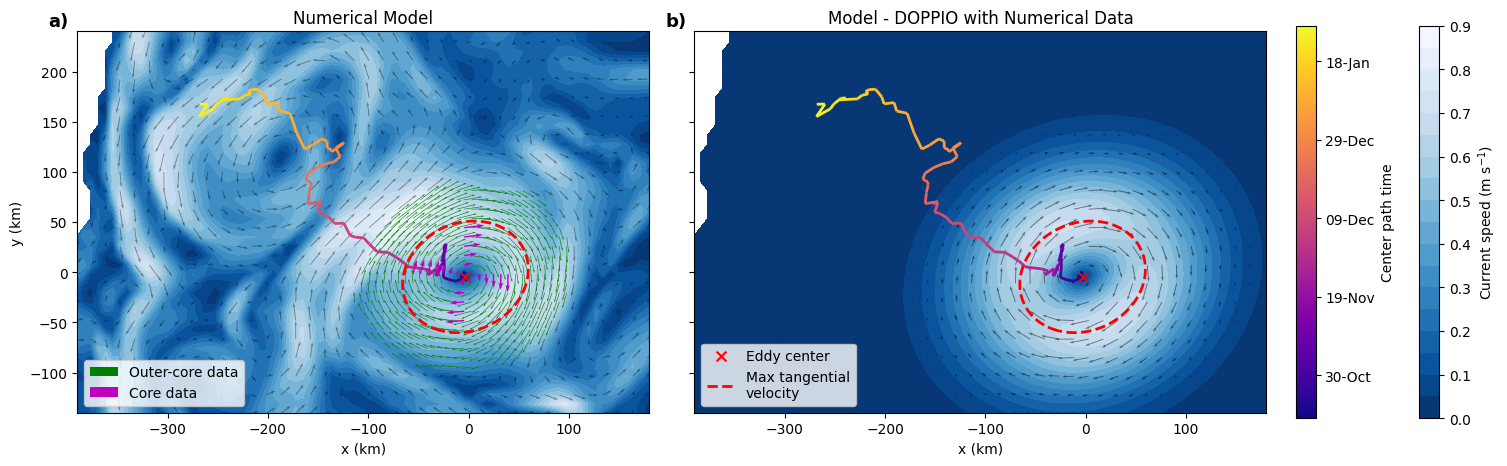

In [12]:
plot__model(df_res, ds_cop, ds_model, df_xyuv, time=df_res.time.values[3], spac=2, out_thresh=False, plot_data=True)


In [13]:
df_paper = df_res.copy()
# df_paper = df_paper.drop(columns='')
df_paper.loc[np.arange(0, 100, 10)]


,xc,yc,w,Q,Omega,time,alpha,Rc,psi0,R2
0,-5111.404592,-843.336429,-0.000036,"[[1.030043830834252, -0.11266275631588453], [-...",-0.000018,2023-10-19 00:00:00,1.121676,84643.475695,63374.641278,0.941574
10,-25316.814045,-5073.499644,-0.000043,"[[1.1299496813576198, 0.15581838205751974], [0...",-0.000021,2023-10-29 00:00:00,1.209955,75741.825227,60920.822240,0.952796
20,-24262.054179,20186.282388,-0.000040,"[[1.2454271090123925, -0.06457777394338052], [...",-0.000020,2023-11-08 00:00:00,1.254727,78528.836378,60205.344140,0.965852
30,-30228.473159,-1614.549712,-0.000035,"[[1.1654209014604455, -0.05650460814662652], [...",-0.000017,2023-11-18 00:00:00,1.175564,95440.447504,77950.269620,0.817092
40,-51560.669447,4217.599725,-0.000035,"[[1.1145709060252544, -0.06701712437598079], [...",-0.000017,2023-11-28 00:00:00,1.133877,91912.569124,72936.953837,0.863334
50,-118145.507641,36734.762478,-0.000043,"[[1.1059776318135168, -0.1380338444303689], [-...",-0.000021,2023-12-08 00:00:00,1.179734,88935.562559,83116.729420,0.772261
60,-159869.033991,69205.029210,-0.000041,"[[1.1989798824584161, -0.17932503692641533], [...",-0.000020,2023-12-17 23:56:15,1.276373,88662.417556,79117.261353,0.661622
70,-127967.688082,115182.987682,-0.000048,"[[0.6279237083120359, -0.05590702214514156], [...",-0.000022,2023-12-28 00:00:00,1.600741,78113.335217,65818.608333,0.524255
80,-163329.324883,122710.202105,-0.000032,"[[1.7528166615525034, -0.13880772181196294], [...",-0.000014,2024-01-07 00:00:00,1.769041,101664.998981,71241.194326,0.772722
90,-216730.281933,177833.964618,-0.000044,"[[0.6674420900881409, -0.05578323360697091], [...",-0.000020,2024-01-17 00:00:00,1.506628,64491.974833,41708.102097,0.761078


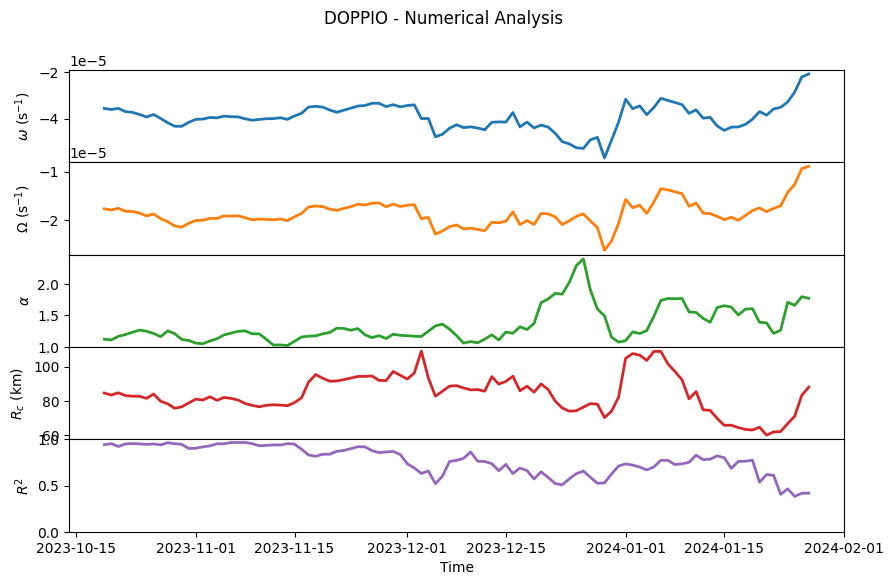

In [14]:
clrs = plt.colormaps['tab10']
fig, axs = plt.subplots(5, 1, figsize=(10,6), sharex=True)
lw = 2

axs[0].plot(df_res.time, df_res.w, color=clrs(0), lw=lw)
axs[0].set_ylabel(r'$\omega$ (s$^{-1}$)')

axs[1].plot(df_res.time, df_res.Omega, color=clrs(1), lw=lw)
axs[1].set_ylabel(r'$\Omega$ (s$^{-1}$)')

axs[2].plot(df_res.time, df_res.alpha, color=clrs(2), lw=lw)
axs[2].set_ylabel(r'$\alpha$')
axs[2].set_ylim(1, None)

axs[3].plot(df_res.time, df_res.Rc/1e3, color=clrs(3), lw=lw)
axs[3].set_ylabel(r'$R_c$ (km)')

axs[4].plot(df_res.time, df_res.R2, color=clrs(4), lw=lw)
axs[4].set_ylabel(r'$R^2$')
axs[4].set_xlabel('Time')
axs[4].set_ylim(0,1)

fig.suptitle("DOPPIO - Numerical Analysis")
fig.subplots_adjust(hspace=0)


In [15]:
# clrs = plt.colormaps['tab10']
# fig, axs = plt.subplots(5, 1, figsize=(10,6), sharex=True)
# lw = 2

# axs[0].plot(df_res.time, df_res.w, color=clrs(0), lw=lw)
# axs[0].set_ylabel(r'$\omega$ (s$^{-1}$)')
# axs[1].plot(df_res.time, df_res.alpha, color=clrs(1), lw=lw)
# axs[1].set_ylabel(r'$\alpha$'); axs[1].set_ylim(1,None)
# axs[2].plot(df_res.time, df_res.Rc/1e3, color=clrs(2), lw=lw)
# axs[2].set_ylabel(r'$R_c$ (km)')
# axs[3].plot(df_res.time, df_res.Omega, color=clrs(3), lw=lw)
# axs[3].set_ylabel(r'$\Omega$ (s$^{-1}$)')
# axs[4].plot(df_res.time, df_res.r2, color=clrs(4), lw=lw)
# axs[4].set_ylabel(r'$R^2$')
# axs[4].set_xlabel('Time'); axs[4].set_ylim(0,1)

# fig.suptitle(f"DOPPIO - Numerical Analysis")

# fig.subplots_adjust(hspace=0)


### Animation

In [16]:
# import os

# def save_model_frames(
#     df_res, ds_cop, ds_model, df_xyuv,
#     outdir="/srv/scratch/z5297792/solo_doppio_latte_paper/doppio_drifter_animation",
#     spac=2, scale=20, xlim=(-410, 200), ylim=(-160, 260),
#     out_thresh=False, plot_data=False, vmax=1.2
# ):
#     os.makedirs(outdir, exist_ok=True)

#     frame_paths = []

#     for t_idx in range(len(df_res)):
#         data = df_res.iloc[t_idx]
#         time = data.time

#         sat = ds_cop.sel(time=time, method="nearest")
#         mod = ds_model.sel(time=time, method="nearest")

#         X = sat.x.values / 1e3
#         Y = sat.y.values / 1e3

#         us, vs = sat.u.values, sat.v.values
#         um, vm = mod.u.values, mod.v.values

#         sp_s = np.hypot(us, vs)
#         sp_m = np.hypot(um, vm)

#         dx = sat.x.values - data.xc
#         dy = sat.y.values - data.yc
#         q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]
#         rho2_grid = q11*dx**2 + 2*q12*dx*dy + q22*dy**2

#         roi = (X >= xlim[0]) & (X <= xlim[1]) & (Y >= ylim[0]) & (Y <= ylim[1])
#         sp_s_roi = np.where(roi, sp_s, np.nan)
#         sp_m_roi = np.where(roi, sp_m, np.nan)
#         roi_quiv = roi & (rho2_grid >= 100_000**2)

#         vals = np.concatenate([sp_s_roi[roi], sp_m_roi[roi]])
#         # vmax = np.nanmax(vals)
#         levels = np.arange(0, vmax + 0.05, 0.05)

#         x_rho = np.linspace(xlim[0]*1e3, xlim[1]*1e3, 100)
#         y_rho = np.linspace(ylim[0]*1e3, ylim[1]*1e3, 100)
#         X_rho, Y_rho = np.meshgrid(x_rho, y_rho)

#         dx = X_rho - data.xc
#         dy = Y_rho - data.yc
#         rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2

#         fig, axs = plt.subplots(1, 2, figsize=(15, 7), sharex=True, sharey=True, constrained_layout=True)

#         # ---- Numerical model ----
#         h0 = axs[0].contourf(X, Y, sp_s_roi, levels=levels, cmap="Blues_r")
#         axs[0].quiver(
#             X[::spac,::spac], Y[::spac,::spac],
#             np.where(roi_quiv[::spac,::spac], us[::spac,::spac], np.nan),
#             np.where(roi_quiv[::spac,::spac], vs[::spac,::spac], np.nan),
#             scale=scale, width=.0015, alpha=.4
#         )
#         axs[0].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50)
#         axs[0].contour(X_rho/1e3, Y_rho/1e3, rho2, levels=[data.Rc**2/2], colors="r", linewidths=2, linestyles="--")
#         axs[0].plot(df_res.xc/1e3, df_res.yc/1e3, color="r", lw=.5)

#         if plot_data:
#             df = df_xyuv[(df_xyuv.time == time) & (df_xyuv.core == "outer")]
#             axs[0].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi, scale=scale, width=.001, color="g", label="Outer-core data")
#             df = df_xyuv[(df_xyuv.time == time) & (df_xyuv.core == "inner")]
#             axs[0].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi, scale=scale, width=.0025, color="m", label="Core data")

#         axs[0].set_title("Numerical Model")
#         axs[0].set_aspect("equal")
#         axs[0].legend(loc="lower left")

#         # ---- Fitted model ----
#         h1 = axs[1].contourf(X, Y, sp_m_roi, levels=levels, cmap="Blues_r")
#         axs[1].quiver(
#             X[::spac,::spac], Y[::spac,::spac],
#             np.where(roi[::spac,::spac], um[::spac,::spac], np.nan),
#             np.where(roi[::spac,::spac], vm[::spac,::spac], np.nan),
#             scale=scale, width=.0015, alpha=.5
#         )
#         axs[1].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50, label="Eddy center")
#         axs[1].contour(X_rho/1e3, Y_rho/1e3, rho2, levels=[data.Rc**2/2], colors="r", linewidths=2, linestyles="--")
#         axs[1].plot([np.nan, np.nan], [np.nan, np.nan], lw=2, color="r", label="Max tangential\nvelocity", ls="--")
#         axs[1].plot(df_res.xc/1e3, df_res.yc/1e3, color="r", lw=.5, label="Center path")
#         axs[1].set_title("Model - DOPPIO with Numerical Data")
#         axs[1].set_aspect("equal")
#         axs[1].legend(loc="lower left")

#         gap = 20
#         for ax in axs:
#             ax.set_xlim(xlim[0] + gap, xlim[1] - gap)
#             ax.set_ylim(ylim[0] + gap, ylim[1] - gap)
#             ax.set_xlabel("x (km)")
#         axs[0].set_ylabel("y (km)")

#         axs[0].text(-0.05, 1.05, "a)", transform=axs[0].transAxes, fontsize=13, fontweight="bold", va="top", ha="left")
#         axs[1].text(-0.05, 1.05, "b)", transform=axs[1].transAxes, fontsize=13, fontweight="bold", va="top", ha="left")

#         fig.colorbar(h1, ax=axs, label="Current speed (m s$^{-1}$)", fraction=0.0165, pad=0.02)
#         fig.suptitle(f"{time}")

#         frame_path = os.path.join(outdir, f"frame_{t_idx:03d}.png")
#         fig.savefig(frame_path, dpi=250, bbox_inches="tight")
#         plt.close(fig)
#         frame_paths.append(frame_path)

#     return 
    

In [17]:
# save_model_frames(
#     df_res, ds_cop, ds_model, df_xyuv,
#     outdir="/srv/scratch/z5297792/solo_doppio_latte_paper/doppio_num_animation",
#     out_thresh=False, plot_data=True
# )
